In [1]:
import argparse
from tbparse import SummaryReader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = None
start_time = 0
iteration_time = 0 
sampling_interval = 0 

In [2]:

def parse_arguments(): 
    parser = argparse.ArgumentParser(
    )
    parser.add_argument(
        "--folder",
        type=str,
        required=True,
        help="Folder in experiment-location where the events file is"
    )
    parser.add_argument(
        "--intervals",
        type=int,
        default=3,
        help="Number of intervals to sample"
    )
    parser.add_argument(
        "--experiment_location",
        default="/fsx/linshuy2/neuronx-distributed-training/examples/nemo_experiments/hf_mixtral/",
        help="Where are the experiment folders"
    )
    return parser

def plotFlops(): 
    # print(df['tag'].unique())
    flops_cond = (df['tag'] ==  'effective_tflops_average') 
    df_flops = df[flops_cond].copy()
    df_flops = df_flops.sort_values(by='wall_time')

    df_flops['elapsed_seconds'] = df_flops['wall_time'] - start_time
    df_flops['interval_bin'] = (df_flops['elapsed_seconds'] // sampling_interval) * sampling_interval
    agg_df = df_flops.groupby('interval_bin')['value'].mean().reset_index()
    agg_df.columns = ['Time (s)', 'Average TFLOPS']

    print(f"Average TFLOPS Max {agg_df['Average TFLOPS'].max()}")
    print("-----Plotting-----")

    plt.figure(figsize=(10, 6))
    
    plt.plot(agg_df['Time (s)'], agg_df['Average TFLOPS'], marker='o', linestyle='-', label=f'{int(sampling_interval)}s Running Average')

    plt.title(f'Effective TFLOPS Averaged per {int(sampling_interval)} Seconds ({args.intervals}x Min Iteration Time)')
    plt.xlabel('Elapsed Time (seconds)')
    plt.ylabel('Effective TFLOPS')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    max_idx = agg_df['Average TFLOPS'].idxmax()
    max_row = agg_df.loc[max_idx]
    
    max_time = max_row['Time (s)']
    max_val = max_row['Average TFLOPS']
    plt.annotate(
        f'Max: {max_val:.2f}',           # The text to display
        xy=(max_time, max_val),          # The point to label (x, y)
        xytext=(0, -40),                 # The position of the text (offset in points)
        textcoords='offset points',      # Interpret xytext as relative pixel offset
        arrowprops=dict(facecolor='red', shrink=0.05), # Arrow style
        fontsize=10,
        fontweight='bold',
        color='red'
    )
    
    # plt.savefig(f'./counter_averages/{args.folder}TFLOPS.png')
    plt.show()

def totalMem():
    tot_mem_cond = (df['tag'] ==  'memory_usage_average') 
    df_tot_mem = df[tot_mem_cond].copy()
    df_tot_mem = df_tot_mem.sort_values(by='wall_time')

    df_tot_mem['elapsed_seconds'] = df_tot_mem['wall_time'] - start_time
    df_tot_mem['interval_bin'] = (df_tot_mem['elapsed_seconds'] // sampling_interval) * sampling_interval
    agg_df = df_tot_mem.groupby('interval_bin')['value'].mean().reset_index()
    agg_df.columns = ['Time (s)', 'Average Memory Usage']

    print(f"Average Memory Max {agg_df['Average Memory Usage'].max()}")
    print("-----Plotting-----")

    plt.figure(figsize=(10, 6))
    
    plt.plot(agg_df['Time (s)'], agg_df['Average Memory Usage'], marker='o', linestyle='-', label=f'{int(sampling_interval)}s Running Average')

    plt.title(f'Total Memory Usage Averaged per {int(sampling_interval)} Seconds ({args.intervals}x Min Iteration Time)')
    plt.xlabel('Elapsed Time (seconds)')
    plt.ylabel('Memory Usage')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    max_idx = agg_df['Average Memory Usage'].idxmax()
    max_row = agg_df.loc[max_idx]
    
    max_time = max_row['Time (s)']
    max_val = max_row['Average Memory Usage']
    plt.annotate(
        f'Max: {max_val:.2f}',           # The text to display
        xy=(max_time, max_val),          # The point to label (x, y)
        xytext=(0, -40),                 # The position of the text (offset in points)
        textcoords='offset points',      # Interpret xytext as relative pixel offset
        arrowprops=dict(facecolor='red', shrink=0.05), # Arrow style
        fontsize=10,
        fontweight='bold',
        color='red'
    )
    
    # plt.savefig(f'./counter_averages/{args.folder}MemoryUsage.png')
    plt.show()


def memory_breakdown_factory(section):
    def memory_breakdown_impl(first_n: int = 32):
        target_tags = [f'memory_breakdown/neuroncore_{i}/{section}' for i in range(first_n)]
        
        tot_mem_cond = df['tag'].isin(target_tags)
        
        df_tot_mem = df[tot_mem_cond].copy()
        df_tot_mem = df_tot_mem.sort_values(by='wall_time')

        df_tot_mem['elapsed_seconds'] = df_tot_mem['wall_time'] - start_time
        df_tot_mem['interval_bin'] = (df_tot_mem['elapsed_seconds'] // sampling_interval) * sampling_interval
        
        # This mean() now averages all values (across all 32 cores) that fall within each time bin
        agg_df = df_tot_mem.groupby('interval_bin')['value'].mean().reset_index()
        agg_df.columns = ['Time (s)', 'Average Memory Usage']

        print(f"Average {section.capitalize()} Memory Max {agg_df['Average Memory Usage'].max()}")
        print("-----Plotting-----")

        plt.figure(figsize=(10, 6))
        
        plt.plot(agg_df['Time (s)'], agg_df['Average Memory Usage'], marker='o', linestyle='-', label=f'{int(sampling_interval)}s Running Average')

        # Updated Title and Labels to reflect the new data source
        plt.title(f'Avg NeuronCore (0-{first_n - 1}) {section.capitalize()} Memory per {int(sampling_interval)} Seconds ({args.intervals}x Min Iteration Time)')
        plt.xlabel('Elapsed Time (seconds)')
        plt.ylabel(f'Average {section.capitalize()} Memory Usage')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend()

        max_idx = agg_df['Average Memory Usage'].idxmax()
        max_row = agg_df.loc[max_idx]
        
        max_time = max_row['Time (s)']
        max_val = max_row['Average Memory Usage']
        plt.annotate(
            f'Max: {max_val:.2f}',           
            xy=(max_time, max_val),          
            xytext=(0, -40),                 
            textcoords='offset points',      
            arrowprops=dict(facecolor='red', shrink=0.05), 
            fontsize=10,
            fontweight='bold',
            color='red'
        )
        
        # Updated filename
        # plt.savefig(f'./counter_averages/{args.folder}NeuronCoreTensorMemory.png')
        plt.show()

    return memory_breakdown_impl

constantMem = memory_breakdown_factory('constants')
tensorMem = memory_breakdown_factory('tensors')
modelCodeMem = memory_breakdown_factory('model_code')
modelSharedScratchpadMem = memory_breakdown_factory('model_shared_scratchpad')
runtimeMem = memory_breakdown_factory('runtime_memory')

def tflops(first_n: int = 32):
    target_tags = [f'effective_tflops/neuroncore_{i}' for i in range(first_n)]
    
    tot_mem_cond = df['tag'].isin(target_tags)
    
    df_tot_mem = df[tot_mem_cond].copy()
    df_tot_mem = df_tot_mem.sort_values(by='wall_time')

    df_tot_mem['elapsed_seconds'] = df_tot_mem['wall_time'] - start_time
    df_tot_mem['interval_bin'] = (df_tot_mem['elapsed_seconds'] // sampling_interval) * sampling_interval
    
    # This mean() now averages all values (across all 32 cores) that fall within each time bin
    agg_df = df_tot_mem.groupby('interval_bin')['value'].mean().reset_index()
    agg_df.columns = ['Time (s)', 'Average TFLOPS']

    print(f"Average TFLOPS Max {agg_df['Average TFLOPS'].max()}")
    print("-----Plotting-----")

    plt.figure(figsize=(10, 6))
    
    plt.plot(agg_df['Time (s)'], agg_df['Average TFLOPS'], marker='o', linestyle='-', label=f'{int(sampling_interval)}s Running Average')

    # Updated Title and Labels to reflect the new data source
    plt.title(f'Avg NeuronCore (0-{first_n - 1}) TFLOPS per {int(sampling_interval)} Seconds ({args.intervals}x Min Iteration Time)')
    plt.xlabel('Elapsed Time (seconds)')
    plt.ylabel('Average TFLOPS')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    max_idx = agg_df['Average TFLOPS'].idxmax()
    max_row = agg_df.loc[max_idx]
    
    max_time = max_row['Time (s)']
    max_val = max_row['Average TFLOPS']
    plt.annotate(
        f'Max: {max_val:.2f}',           
        xy=(max_time, max_val),          
        xytext=(0, -40),                 
        textcoords='offset points',      
        arrowprops=dict(facecolor='red', shrink=0.05), 
        fontsize=10,
        fontweight='bold',
        color='red'
    )
    
    # Updated filename
    # plt.savefig(f'./counter_averages/{args.folder}NeuronCoreTFLOPS.png')
    plt.show()

def total_memory(first_n: int = 32):
    target_tags = [f'memory_usage/neuroncore_{i}' for i in range(first_n)]
    
    tot_mem_cond = df['tag'].isin(target_tags)
    
    df_tot_mem = df[tot_mem_cond].copy()
    df_tot_mem = df_tot_mem.sort_values(by='wall_time')

    df_tot_mem['elapsed_seconds'] = df_tot_mem['wall_time'] - start_time
    df_tot_mem['interval_bin'] = (df_tot_mem['elapsed_seconds'] // sampling_interval) * sampling_interval
    
    # This mean() now averages all values (across all 32 cores) that fall within each time bin
    agg_df = df_tot_mem.groupby('interval_bin')['value'].mean().reset_index()
    agg_df.columns = ['Time (s)', 'Average Memory Usage']

    print(f"Average Memory Max {agg_df['Average Memory Usage'].max()}")
    print("-----Plotting-----")

    plt.figure(figsize=(10, 6))
    
    plt.plot(agg_df['Time (s)'], agg_df['Average Memory Usage'], marker='o', linestyle='-', label=f'{int(sampling_interval)}s Running Average')

    # Updated Title and Labels to reflect the new data source
    plt.title(f'Avg NeuronCore (0-{first_n - 1}) Memory Usage per {int(sampling_interval)} Seconds ({args.intervals}x Min Iteration Time)')
    plt.xlabel('Elapsed Time (seconds)')
    plt.ylabel('Average Memory Usage')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    max_idx = agg_df['Average Memory Usage'].idxmax()
    max_row = agg_df.loc[max_idx]
    
    max_time = max_row['Time (s)']
    max_val = max_row['Average Memory Usage']
    plt.annotate(
        f'Max: {max_val:.2f}',           
        xy=(max_time, max_val),          
        xytext=(0, -40),                 
        textcoords='offset points',      
        arrowprops=dict(facecolor='red', shrink=0.05), 
        fontsize=10,
        fontweight='bold',
        color='red'
    )
    
    # Updated filename
    # plt.savefig(f'./counter_averages/{args.folder}NeuronCoreTotalMemory.png')
    plt.show()

def loss(first_n: int = 500, other_df=None):
    loss_cond = (df['tag'] ==  'reduced_train_loss') 
    df_loss = df[loss_cond].copy()
    df_loss = df_loss.sort_values(by='wall_time')

    plt.figure(figsize=(10, 6))
    
    plt.plot(
        df_loss['step'][:first_n], 
        df_loss['value'][:first_n], 
        marker='o', 
        linestyle='-', 
        label='Training Loss' if other_df is None else 'Ours',
        markersize=2
    )

    if other_df is not None:
        other_loss_cond = (other_df['tag'] ==  'reduced_train_loss') 
        other_df_loss = other_df[other_loss_cond].copy()
        other_df_loss = other_df_loss.sort_values(by='wall_time')

        plt.plot(
            other_df_loss['step'][:first_n], 
            other_df_loss['value'][:first_n], 
            marker='o', 
            linestyle='-', 
            label='Baseline',
            markersize=2
        )

    plt.title(f'Training Loss over First {first_n} Steps')
    plt.xlabel('Training Step')
    plt.ylabel('Reduced Training Loss')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    # plt.savefig(f'./counter_averages/{args.folder}TrainingLoss.png')
    plt.show()

In [13]:
import sys

args = [
    "--folder", "617",
]

first_n = 32

sys.argv.extend(args)

In [14]:

import os

 
parser = parse_arguments()
args = parser.parse_args()

log_dir = args.experiment_location 
experiment = args.folder

if not os.path.exists('./df_storage/'):
    os.makedirs('./df_storage/')

df = None 
try:
    df = pd.read_pickle(f'./df_storage/{str(experiment)}Dataframe.pkl')
except FileNotFoundError: 
    reader = SummaryReader(log_dir + experiment, extra_columns={'wall_time', 'dir_name', 'file_name'})
    df = reader.scalars
    df.to_pickle(f'./df_storage/{str(experiment)}Dataframe.pkl')
 
iteration_cond = (df['tag'] ==  'train_step_timing') 
df_iteration = df[iteration_cond].copy()

iteration_time = df_iteration['value'].min()
print(iteration_time)

start_time = df['wall_time'].min()
sampling_interval = iteration_time * args.intervals

444.2654113769531


Average TFLOPS Max 21.314918099685126
-----Plotting-----


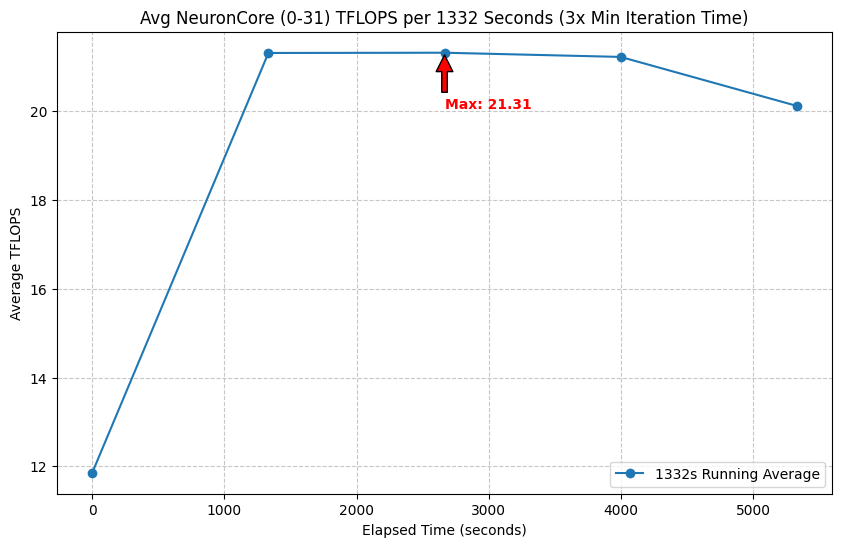

In [15]:
tflops(first_n=first_n)

Average Memory Max 12.842667948511338
-----Plotting-----


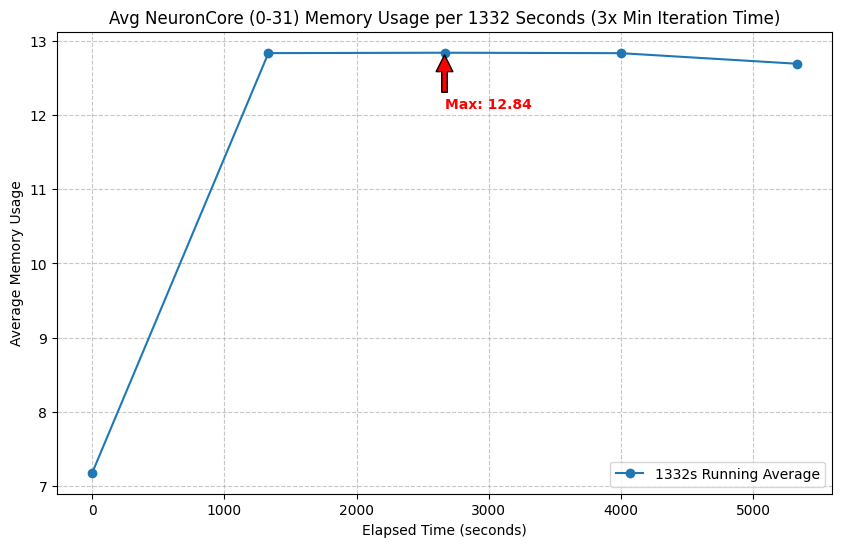

In [16]:
total_memory(first_n=first_n)


Average Constants Memory Max 1.238291798572845
-----Plotting-----


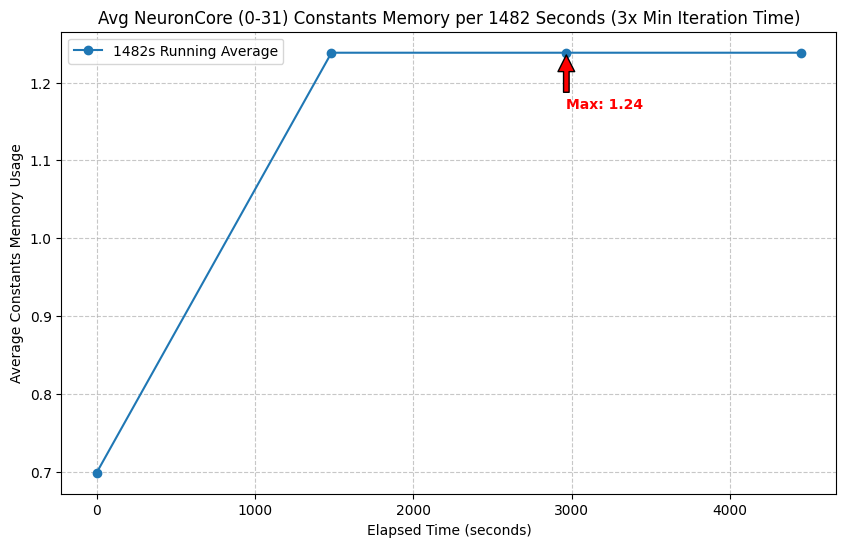

In [58]:
constantMem(first_n=first_n)

Average Tensors Memory Max 7.753215544727728
-----Plotting-----


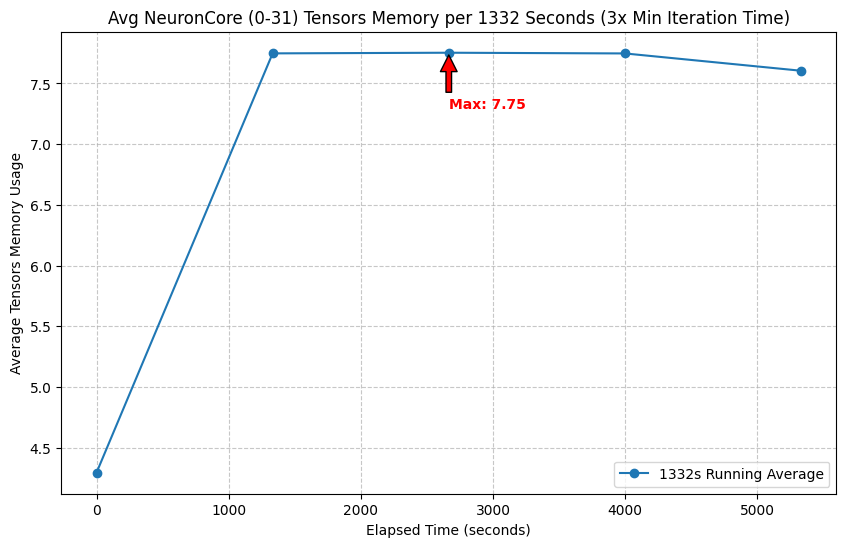

In [17]:
tensorMem(first_n=first_n)

Average Model_code Memory Max 0.945342193157486
-----Plotting-----


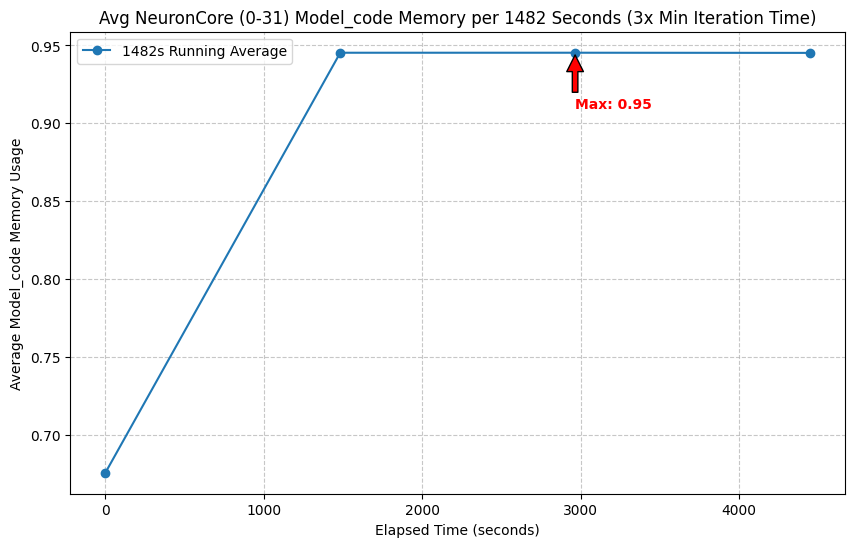

In [60]:
modelCodeMem(first_n=first_n)

Average Model_shared_scratchpad Memory Max 2.500000238418579
-----Plotting-----


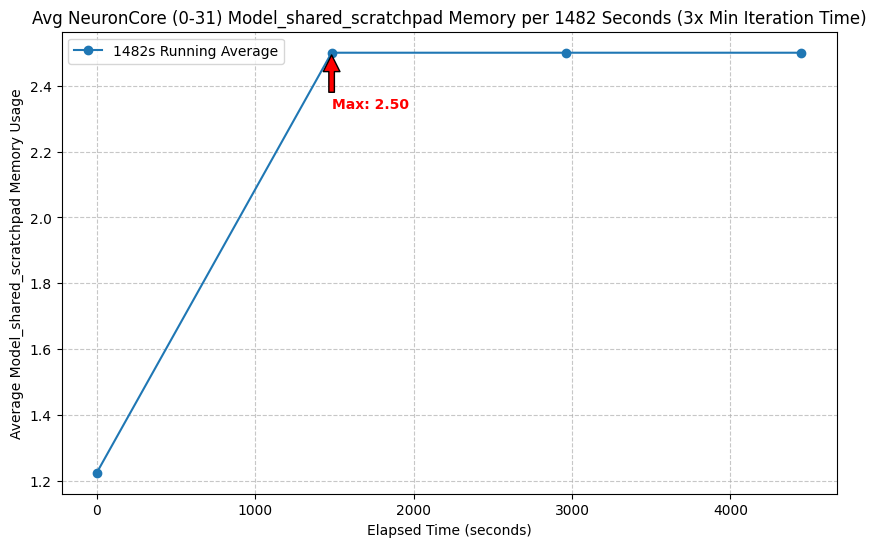

In [61]:
modelSharedScratchpadMem(first_n=first_n)

Average Runtime_memory Memory Max 0.001649152695729594
-----Plotting-----


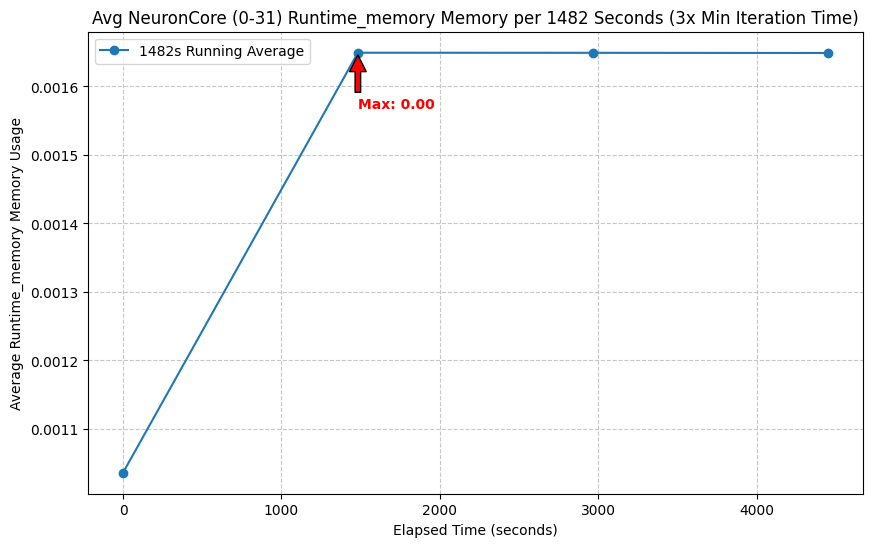

In [62]:
runtimeMem(first_n=first_n)

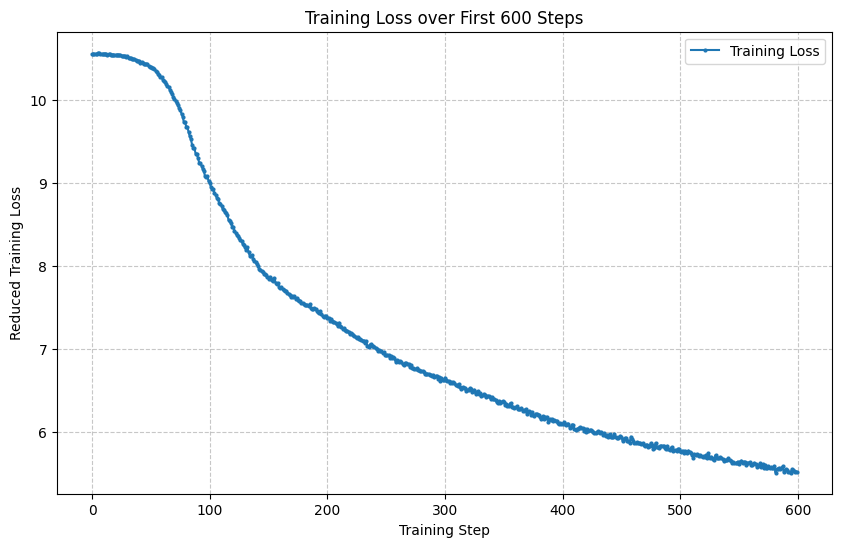

In [11]:

# df_baseline = df.copy()
df_baseline = None

loss(first_n=600, other_df=df_baseline)

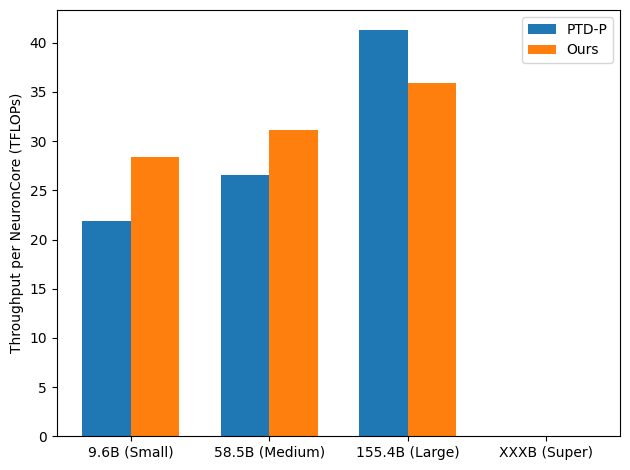

Speedups: [1.3005489478499543, 1.1703647987965402, 0.8696389629270657]
Max Speedup: 1.30x


In [30]:
import numpy as np
import matplotlib.pyplot as plt

# 4 categories on the x-axis
# categories = ["6.3B (Small)", "47.5B (Medium)", "164.7B (Large)", "XXXB (Super)"]
categories = ["9.6B (Small)", "58.5B (Medium)", "155.4B (Large)", "XXXB (Super)"]

# Two bar-series (2 bars per category)
# baseline = [7.34, 13.49, 14.99, 0]
# ours = [23.83, 34.49, 30.62, 0] 
baseline = [21.86, 26.59, 41.27, 0]
ours = [28.43, 31.12, 35.89, 0]

x = np.arange(len(categories))   # [0,1,2,3]
width = 0.35                     # width of each bar

fig, ax = plt.subplots()

ax.bar(x - width/2, baseline, width, label="PTD-P")
ax.bar(x + width/2, ours, width, label="Ours")

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel("Throughput per NeuronCore (TFLOPs)")
# ax.set_title("Grouped Bar Chart (4 categories, 2 bars each)")
ax.legend()

plt.tight_layout()
plt.show()

speedups = [s2 / s1 for s1, s2 in zip(baseline, ours) if s1 > 0]
print(f"Speedups: {speedups}")
print(f"Max Speedup: {max(speedups):.2f}x")

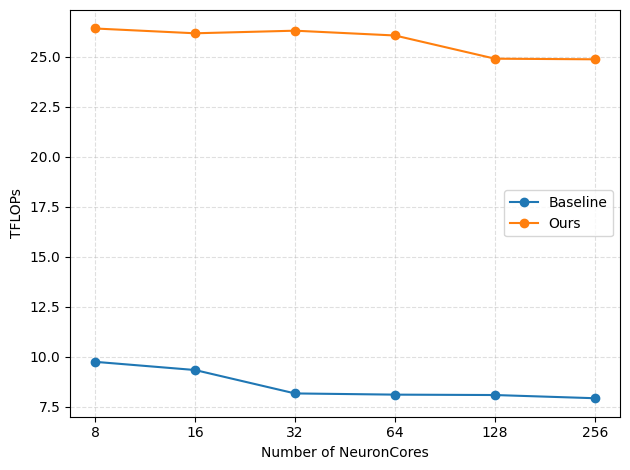

In [ ]:
import matplotlib.pyplot as plt

# X axis (e.g., months)
x = [8, 16, 32, 64, 128, 256]

# Two categories (two lines)
baseline = [9.75, 9.34, 8.17, 8.11, 8.09, 7.93]
ours = [26.41, 26.17, 26.30, 26.06, 24.90, 24.87]

plt.plot(x, baseline, marker="o", label="Baseline")
plt.plot(x, ours, marker="o", label="Ours")
plt.xscale("log", base=2)
plt.xticks(x, x)

# plt.title("Line Chart with Two Categories")
plt.xlabel("Number of NeuronCores")
plt.ylabel("TFLOPs")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


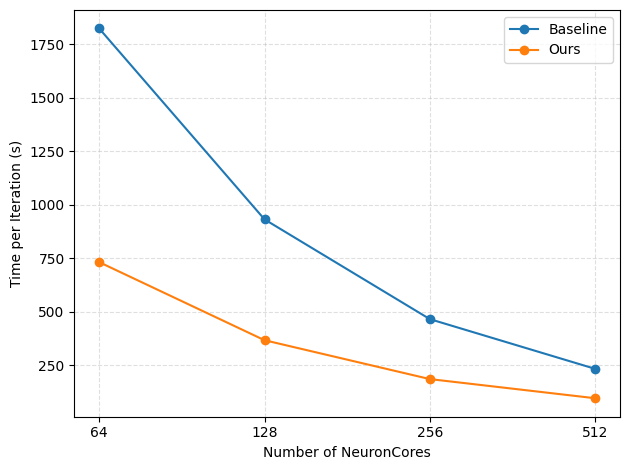

Decrease Ratios: [2.4897786511640603, 2.533923864902318, 2.502091601415853, 2.414845360824742]
Max Decrease Ratio: 2.53x


In [15]:
import matplotlib.pyplot as plt

# X axis (e.g., months)
x = [64, 128, 256, 512]

# Two categories (two lines)
baseline = [1824.46, 932.56, 466.54, 234.24]
ours = [732.78, 368.03, 186.46, 97.00]

plt.plot(x, baseline, marker="o", label="Baseline")
plt.plot(x, ours, marker="o", label="Ours")
plt.xscale("log", base=2)
plt.xticks(x, x)

# plt.title("Line Chart with Two Categories")
plt.xlabel("Number of NeuronCores")
plt.ylabel("Time per Iteration (s)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

decrease_ratios = [b / o for b, o in zip(baseline, ours)]
print(f"Decrease Ratios: {decrease_ratios}")
print(f"Max Decrease Ratio: {max(decrease_ratios):.2f}x")

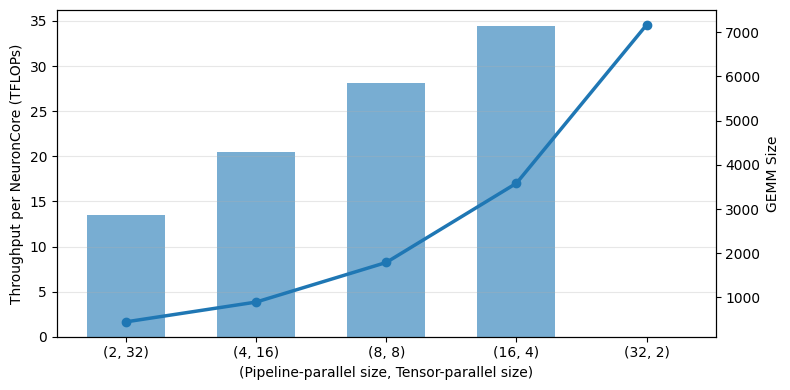

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Fake example data
# ---------------------------
x_labels = ["(2, 32)", "(4, 16)", "(8, 8)", "(16, 4)", "(32, 2)"]
x = np.arange(len(x_labels))

# Left Y-axis (bar)
bar_values = np.array([13.49, 20.51, 28.07, 34.49, 0])

# Right Y-axis (line) — two categories
line_cat_a = np.array([448, 896, 1792, 3584, 7168])
# line_cat_b = np.array([2.2, 1.9, 2.6, 2.1, 2.9])
# ---------------------------
# Plot
# ---------------------------
fig, ax_left = plt.subplots(figsize=(8, 4))

# Bars (put behind)
bars = ax_left.bar(
    x,
    bar_values,
    width=0.6,
    alpha=0.6,      # <-- makes overlap less confusing
    zorder=1,       # <-- bars behind
    # label="Throughput per NeuronCore (TFLOPs)",
)
ax_left.set_ylabel("Throughput per NeuronCore (TFLOPs)")
ax_left.set_xlabel("(Pipeline-parallel size, Tensor-parallel size)")
ax_left.set_xticks(x)
ax_left.set_xticklabels(x_labels)

# Grid behind everything
ax_left.grid(True, axis="y", alpha=0.3, zorder=0)

# Right axis (lines)
ax_right = ax_left.twinx()

# Make the right axis draw ON TOP of the left axis artists
ax_right.set_zorder(ax_left.get_zorder() + 1)
ax_right.patch.set_visible(False)  # don't cover the bars with a white background

line1, = ax_right.plot(
    x, line_cat_a, marker="o", linewidth=2.5, zorder=3, label="Line category A"
)
# line2, = ax_right.plot(
#     x, line_cat_b, marker="s", linewidth=2.5, zorder=3, label="Line category B"
# )
ax_right.set_ylabel("GEMM Size")

# plt.title("Two Y-Axes: Bars (Left) + Two-Line Categories (Right)")

# Combined legend
# handles_left, labels_left = ax_left.get_legend_handles_labels()
# handles_right, labels_right = ax_right.get_legend_handles_labels()
# ax_left.legend(handles_left + handles_right, labels_left + labels_right, loc="upper left")

plt.tight_layout()
plt.show()


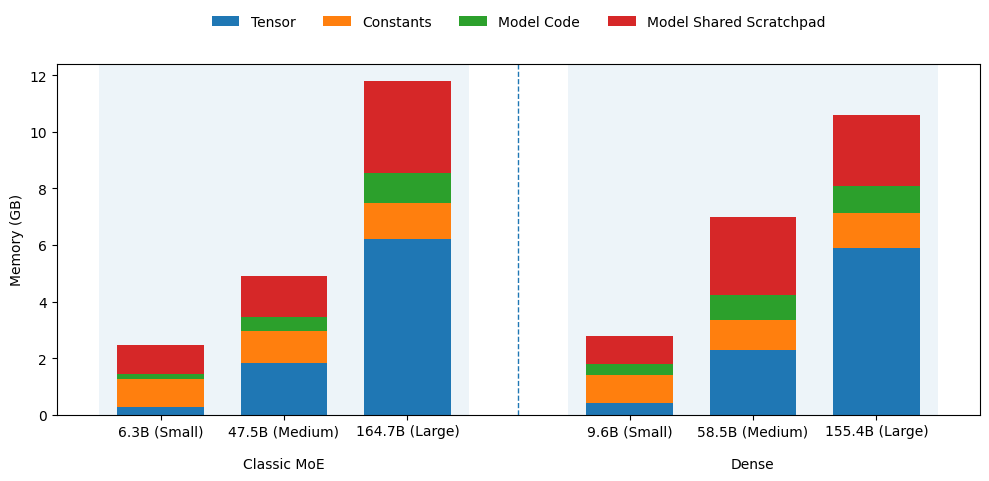

In [64]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Example data: 6 bars, each stacked from 4 parts ----
labels = [
    # Classic MoE:
    "6.3B (Small)","47.5B (Medium)","164.7B (Large)",
    # Expert-specialized MoE:
    # "6.3B (Small)","47.5B (Medium)","164.7B (Large)"
    # Dense
    "9.6B (Small)","58.5B (Medium)","155.4B (Large)"
]   # x-axis labels
parts = np.array([
    [0.2608, 1.8202, 6.2037] # Tensor
    # + [0.3598, 2.0251, 0],  
    + [0.4249, 2.2970, 5.8973],
    [1.0158, 1.1528, 1.2825] # Constants 
    # + [1.0153, 1.1544, 0],  
    + [0.9824, 1.0551, 1.2383],
    [0.1801, 0.4860, 1.0771] # Model Code 
    # + [0.3055, 0.8557, 0],  
    + [0.3804, 0.8898, 0.9453],
    [1.0000, 1.4377, 3.2504] # Model Shared Scratchpad
    # + [1.0000, 3.8128, 0],  
    + [1.0000, 2.7501, 2.5000],
])

# ---- Create positions with a visible gap between bar 3 and 4 ----
x = np.arange(6, dtype=float)
gap = 0.8
x[3:] += gap  # shift bars 4-6 to the right

fig, ax = plt.subplots(figsize=(10, 5))

ax.axvspan(x[0]-0.5, x[2]+0.5, alpha=0.08)
ax.axvspan(x[3]-0.5, x[5]+0.5, alpha=0.08)

stacks = ["Tensor", "Constants", "Model Code", "Model Shared Scratchpad"]
bottom = np.zeros(6)
for i in range(parts.shape[0]):
    ax.bar(x, parts[i], bottom=bottom, width=0.7, label=stacks[i])
    bottom += parts[i]

# x ticks/labels
ax.set_xticks(x)
ax.set_xticklabels(labels)

# ---- Group labels under the axis ----
# centers of each group
group1_center = np.mean(x[:3])
group2_center = np.mean(x[3:])

ax.text(group1_center, -0.12, "Classic MoE", ha="center", va="top",
        transform=ax.get_xaxis_transform())
ax.text(group2_center, -0.12, 
        # "Expert-specialized MoE", 
        "Dense",
        ha="center", va="top",
        transform=ax.get_xaxis_transform())

# optional: a vertical separator line in the gap
ax.axvline((x[2] + x[3]) / 2, linestyle="--", linewidth=1)

ax.set_ylabel("Memory (GB)")

# add a text to explain the last one OOM
# ax.text(x[5], bottom[5] + 0.2, "OOM", ha="center", va="bottom", color="red")

ax.legend(ncols=4, bbox_to_anchor=(0.5, 1.12), loc="center", frameon=False)

plt.tight_layout()
plt.show()